# EDA

Размер train: (200000, 202)
Размер test: (200000, 201)
Пропусков в train: 0
Пропусков в test: 0

Распределение целевой переменной:
Класс 0: 89.95%
Класс 1: 10.05%


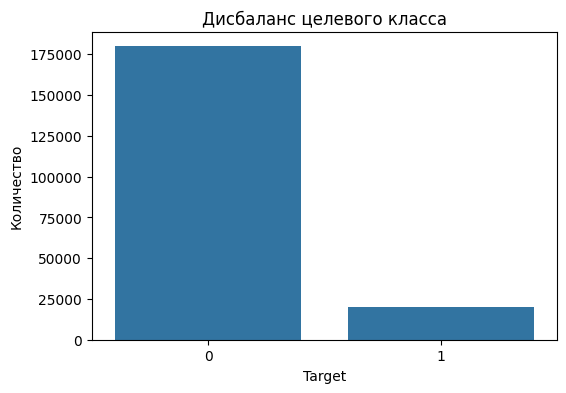

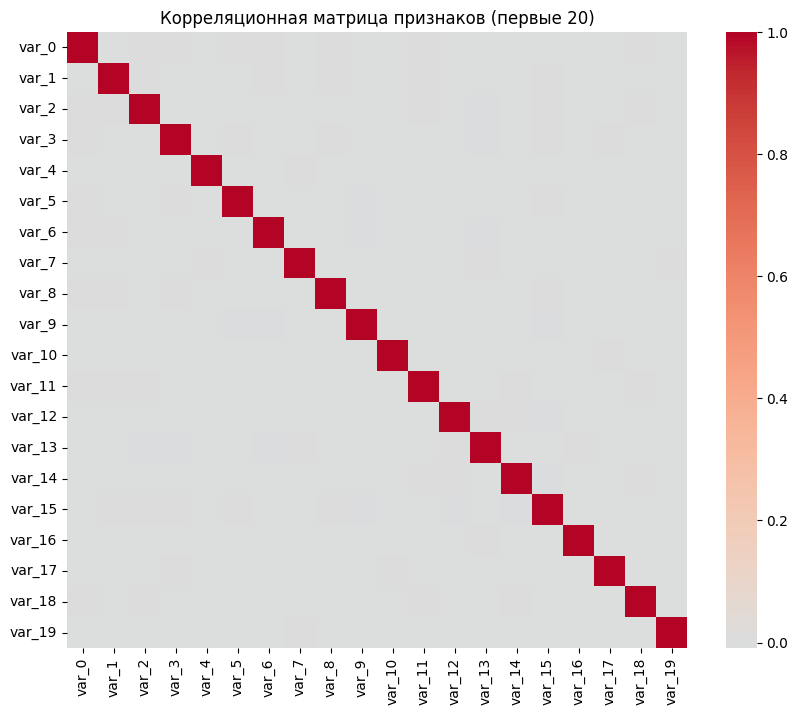


Средняя корреляция признаков: 0.0020


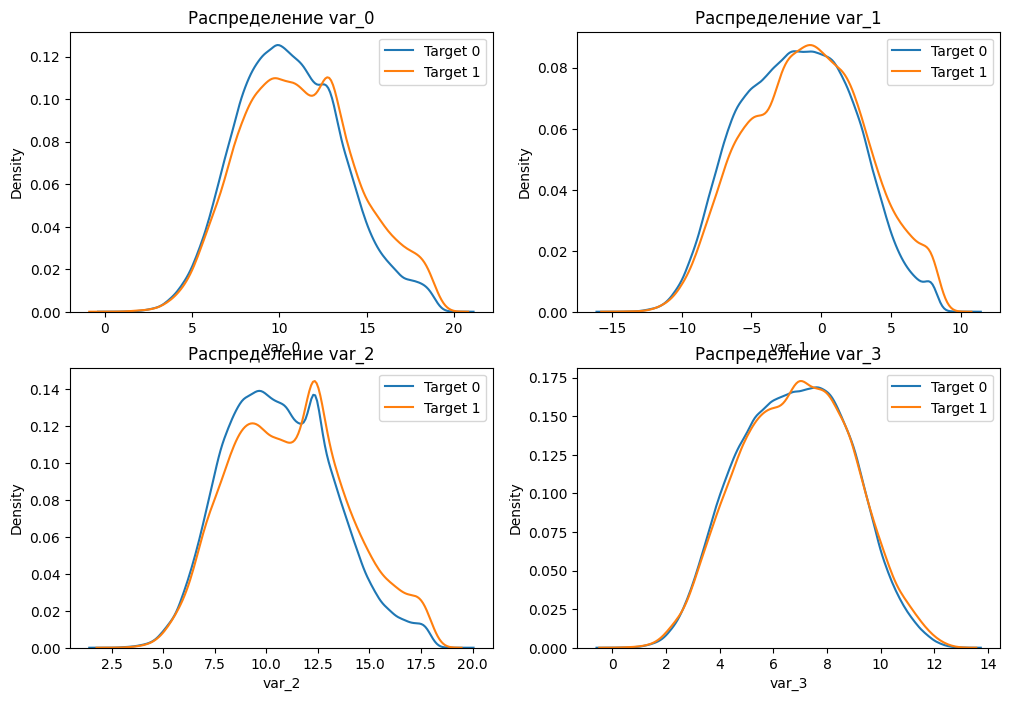


Статистика по кол-ву уникальных значений в колонках:
count       200.00000
mean      97906.72000
std       43599.73225
min         451.00000
25%       64400.00000
50%      108872.50000
75%      133935.25000
max      169968.00000
dtype: float64


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

features = [col for col in train.columns if col.startswith("var_")]

print(f"Размер train: {train.shape}")
print(f"Размер test: {test.shape}")
print(f"Пропусков в train: {train.isna().sum().sum()}")
print(f"Пропусков в test: {test.isna().sum().sum()}")

target_counts = train["target"].value_counts(normalize=True)
print("\nРаспределение целевой переменной:")
print(f"Класс 0: {target_counts[0]:.2%}")
print(f"Класс 1: {target_counts[1]:.2%}")

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=train)
plt.title("Дисбаланс целевого класса")
plt.xlabel("Target")
plt.ylabel("Количество")
plt.show()

corr_matrix = train[features[:20]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Корреляционная матрица признаков (первые 20)")
plt.show()

mean_corr = (
    np.abs(train[features].corr().values)[
        ~np.eye(len(features), dtype=bool)].mean())
print(f"\nСредняя корреляция признаков: {mean_corr:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(features[:4]):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(train[train["target"] == 0][col], ax=ax, label="Target 0")
    sns.kdeplot(train[train["target"] == 1][col], ax=ax, label="Target 1")
    ax.set_title(f"Распределение {col}")
    ax.legend()

plt.show()
unique_counts = train[features].nunique()
print("\nСтатистика по кол-ву уникальных значений в колонках:")
print(unique_counts.describe())

# 1 version - LGBM

In [2]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

features = [col for col in train.columns[2:]]
X, y = train[features], train["target"]
X_test = test[features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
model = LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, random_state=17)

oof = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
print(f"Baseline ROC-AUC = {roc_auc_score(y, oof):.5f}")

model.fit(X, y)
test_preds = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"ID_code": test["ID_code"], "target": test_preds})
submission.to_csv("submission_baseline.csv", index=False)

[LightGBM] [Info] Number of positive: 16079, number of negative: 143921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100494 -> initscore=-2.191750
[LightGBM] [Info] Start training from score -2.191750
[LightGBM] [Info] Number of positive: 16079, number of negative: 143921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100494 -> initscore=-2.191750
[LightGBM] [Info] Start training from score -2.191750
[Lig

# 2 version feature engineering - из discussion
- (дробные значения (например, 11.5342) не уникальны для каждого человека, а повторяются в датасете десятки и сотни раз)

- Мы создаем новую колонку var_0_freq. Если значение 11.5342 встречается в данных 50 раз, модель получает явный признак со значением 50

- Раз перемножать признаки не имеет смысла - будем получать ноль, то будем считать суммы, средние и т.д. по каждому объекту и из них делать выводы



In [6]:
orig_features = [col for col in train.columns[2:]]
for col in orig_features:
    freq = pd.concat([train[col], test[col]]).value_counts()
    train[f"{col}_freq"] = train[col].map(freq)
    test[f"{col}_freq"] = test[col].map(freq)

print("Расчет статистик по строкам")
train["row_mean"] = train[orig_features].mean(axis=1)
train["row_std"] = train[orig_features].std(axis=1)
train["row_min"] = train[orig_features].min(axis=1)
train["row_max"] = train[orig_features].max(axis=1)
train["row_sum"] = train[orig_features].sum(axis=1)

test["row_mean"] = test[orig_features].mean(axis=1)
test["row_std"] = test[orig_features].std(axis=1)
test["row_min"] = test[orig_features].min(axis=1)
test["row_max"] = test[orig_features].max(axis=1)
test["row_sum"] = test[orig_features].sum(axis=1)

features = [col for col in train.columns if col not in ["ID_code", "target"]]
X, y = train[features], train["target"]
X_test = test[features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

model = LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=16,
    random_state=17)

oof = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
cv_score = roc_auc_score(y, oof)
print(f"v2 CV ROC-AUC = {cv_score:.5f}")

model.fit(X, y)
test_preds = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"ID_code": test["ID_code"], "target": test_preds})
submission.to_csv("submission_v2_fe.csv", index=False)

/var/folders/2h/595lthl56gg578s10l94v_800000gn/T/ipykernel_34266/1552280972.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_freq"] = train[col].map(freq)
/var/folders/2h/595lthl56gg578s10l94v_800000gn/T/ipykernel_34266/1552280972.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[f"{col}_freq"] = test[col].map(freq)


Расчет статистик по строкам...


/var/folders/2h/595lthl56gg578s10l94v_800000gn/T/ipykernel_34266/1552280972.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["row_mean"] = train[orig_features].mean(axis=1)
/var/folders/2h/595lthl56gg578s10l94v_800000gn/T/ipykernel_34266/1552280972.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["row_std"] = train[orig_features].std(axis=1)
/var/folders/2h/595lthl56gg578s10l94v_800000gn/T/ipykernel_34266/1552280972.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

[LightGBM] [Info] Number of positive: 16079, number of negative: 143921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58430
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 405
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100494 -> initscore=-2.191750
[LightGBM] [Info] Start training from score -2.191750
[LightGBM] [Info] Number of positive: 16079, number of negative: 143921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071728 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58434
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 405
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100494 -> initscore=-2.191750
[LightGBM] [Info] Start training from score -2.191750
[Lig

# version 3 - catboost & xgboost 

In [7]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

features = [col for col in train.columns if col not in ["ID_code", "target"]]
X, y = train[features], train["target"]
X_test = test[features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
print('catboost')
cb_model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    random_seed=17,
    verbose=200)

oof_cb = cross_val_predict(cb_model, X, y, cv=skf, method='predict_proba')[:, 1]
cv_cb = roc_auc_score(y, oof_cb)
print(f"catboost CV ROC-AUC = {cv_cb:.5f}")

cb_model.fit(X, y)
preds_test_cb = cb_model.predict_proba(X_test)[:, 1]



print('xgboost')
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    eval_metric="auc",
    random_state=17)

oof_xgb = cross_val_predict(xgb_model, X, y, cv=skf, method="predict_proba")[:, 1]
cv_xgb = roc_auc_score(y, oof_xgb)
print(f"xgboost ROC-AUC = {cv_xgb:.5f}")

xgb_model.fit(X, y)
preds_test_xgb = xgb_model.predict_proba(X_test)[:, 1]

catboost
0:	total: 92.2ms	remaining: 2m 18s
200:	total: 4.32s	remaining: 27.9s
400:	total: 8.86s	remaining: 24.3s
600:	total: 13.6s	remaining: 20.3s
800:	total: 18.4s	remaining: 16.1s
1000:	total: 23.7s	remaining: 11.8s
1200:	total: 28.8s	remaining: 7.18s
1400:	total: 33.9s	remaining: 2.39s
1499:	total: 36.4s	remaining: 0us
0:	total: 30.3ms	remaining: 45.4s
200:	total: 4.67s	remaining: 30.2s
400:	total: 9.61s	remaining: 26.3s
600:	total: 14.8s	remaining: 22.1s
800:	total: 20s	remaining: 17.5s
1000:	total: 25.2s	remaining: 12.6s
1200:	total: 30.6s	remaining: 7.61s
1400:	total: 35.6s	remaining: 2.52s
1499:	total: 38.2s	remaining: 0us
0:	total: 30ms	remaining: 45s
200:	total: 4.9s	remaining: 31.7s
400:	total: 10.3s	remaining: 28.3s
600:	total: 15.7s	remaining: 23.5s
800:	total: 21.2s	remaining: 18.5s
1000:	total: 26.6s	remaining: 13.3s
1200:	total: 32.3s	remaining: 8.04s
1400:	total: 37.4s	remaining: 2.64s
1499:	total: 40s	remaining: 0us
0:	total: 29.6ms	remaining: 44.4s
200:	total: 4.86s

# version 3.5 - подбор гиперпараметров через (optuna) - решил выбрать RandomCV 

In [10]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.5 MB/s  0:00:006.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]━━━━ 4/5 [optuna]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

# Берем подвыборку 50_000 строк для быстрого поиска параметров
sample = train.sample(n=50000, random_state=17)
X_sample = sample[features]
y_sample = sample["target"]

param_dist = {
    "num_leaves": [15, 31, 45],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.6, 0.8],
    "min_child_samples": [20, 50, 100]}

fast_search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        n_estimators=150, random_state=17, n_jobs=-1, verbose=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=17,
    n_jobs=-1,)

print("Запуск быстрого подбора")
fast_search.fit(X_sample, y_sample)

print("Лучшие параметры:", fast_search.best_params_)

Запуск быстрого подбора...
Лучшие параметры: {'subsample': 0.7, 'num_leaves': 15, 'min_child_samples': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# проверка на version 2 

In [5]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

orig_features = [col for col in train.columns if col.startswith("var_")]

row_stats_train = pd.DataFrame(
    {
        "row_mean": train[orig_features].mean(axis=1),
        "row_std": train[orig_features].std(axis=1),
        "row_min": train[orig_features].min(axis=1),
        "row_max": train[orig_features].max(axis=1),
        "row_sum": train[orig_features].sum(axis=1),})

row_stats_test = pd.DataFrame(
    {
        "row_mean": test[orig_features].mean(axis=1),
        "row_std": test[orig_features].std(axis=1),
        "row_min": test[orig_features].min(axis=1),
        "row_max": test[orig_features].max(axis=1),
        "row_sum": test[orig_features].sum(axis=1),})

train = pd.concat([train, row_stats_train], axis=1)
test = pd.concat([test, row_stats_test], axis=1)

features = [col for col in train.columns if col not in ["ID_code", "target"]]
X, y = train[features], train["target"]
X_test = test[features]

tuned_params = {
    "num_leaves": 15,
    "max_depth": 5,
    "min_child_samples": 100,
    "subsample": 0.7,
    "colsample_bytree": 0.8,
    "learning_rate": 0.05,
    "n_estimators": 1200,
    "random_state": 17,
    "n_jobs": -1,
    "verbose": -1}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
model = LGBMClassifier(**tuned_params)

print("Запуск 5-Fold Cross-Validation...")
oof = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
cv_score = roc_auc_score(y, oof)
print(f"Iteration v2.1 CV ROC-AUC = {cv_score:.5f}")


model.fit(X, y)
test_preds = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"ID_code": test["ID_code"], "target": test_preds})
submission.to_csv("submission_v3_tuned.csv", index=False)

Запуск 5-Fold Cross-Validation...
Iteration v2.1 CV ROC-AUC = 0.89336


# version 4 - блендинг

In [8]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

orig_features = [col for col in train.columns if col.startswith("var_")]
train_freq_dict, test_freq_dict = {}, {}
for col in orig_features:
    freq = pd.concat([train[col], test[col]]).value_counts()
    train_freq_dict[f"{col}_freq"] = train[col].map(freq)
    test_freq_dict[f"{col}_freq"] = test[col].map(freq)

train = pd.concat([train, pd.DataFrame(train_freq_dict)], axis=1)
test = pd.concat([test, pd.DataFrame(test_freq_dict)], axis=1)

row_stats_train = pd.DataFrame({
    "row_mean": train[orig_features].mean(axis=1),
    "row_std": train[orig_features].std(axis=1),
    "row_min": train[orig_features].min(axis=1),
    "row_max": train[orig_features].max(axis=1),
    "row_sum": train[orig_features].sum(axis=1),})

row_stats_test = pd.DataFrame({
    "row_mean": test[orig_features].mean(axis=1),
    "row_std": test[orig_features].std(axis=1),
    "row_min": test[orig_features].min(axis=1),
    "row_max": test[orig_features].max(axis=1),
    "row_sum": test[orig_features].sum(axis=1),})

train = pd.concat([train, row_stats_train], axis=1)
test = pd.concat([test, row_stats_test], axis=1)

features = [col for col in train.columns if col not in ["ID_code", "target"]]
X, y = train[features], train["target"]
X_test = test[features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

def evaluate_model(model, X, y, cv):
    oof_preds = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
    return oof_preds

lgb_params = {
    "num_leaves": 15, "max_depth": 5, "min_child_samples": 100,
    "learning_rate": 0.05, "n_estimators": 1200, "subsample": 0.7,
    "colsample_bytree": 0.8, "random_state": 17, "n_jobs": -1, "verbose": -1}
model_lgb = LGBMClassifier(**lgb_params)
oof_lgb = evaluate_model(model_lgb, X, y, skf)

cb_params = {
    "iterations": 1200, "learning_rate": 0.05, "depth": 6,
    "eval_metric": "AUC", "random_seed": 17, "verbose": 0, "thread_count": -1}
model_cb = CatBoostClassifier(**cb_params)
oof_cb = evaluate_model(model_cb, X, y, skf)

xgb_params = {
    "n_estimators": 1000, "learning_rate": 0.05, "max_depth": 4,
    "subsample": 0.7, "colsample_bytree": 0.8, "eval_metric": "auc",
    "random_state": 17, "n_jobs": -1, "tree_method": "hist"}
model_xgb = XGBClassifier(**xgb_params)
oof_xgb = evaluate_model(model_xgb, X, y, skf)

# подбор весов ансамбля
def ensemble_objective(weights):
    blend = weights[0] * oof_lgb + weights[1] * oof_cb + weights[2] * oof_xgb
    return -roc_auc_score(y, blend)

res = minimize(
    ensemble_objective, 
    x0=[1/3, 1/3, 1/3], 
    method="SLSQP", 
    bounds=[(0, 1), (0, 1), (0, 1)], 
    constraints={"type": "eq", "fun": lambda w: 1.0 - np.sum(w)})

w_lgb, w_cb, w_xgb = res.x

print(f"Оптимальные веса: LGBM: {w_lgb:.3f} | CB: {w_cb:.3f} | XGB: {w_xgb:.3f}")
print(f"Final Ensemble CV ROC-AUC: {-res.fun:.5f}")

model_lgb.fit(X, y)
preds_lgb = model_lgb.predict_proba(X_test)[:, 1]

model_cb.fit(X, y)
preds_cb = model_cb.predict_proba(X_test)[:, 1]

model_xgb.fit(X, y)
preds_xgb = model_xgb.predict_proba(X_test)[:, 1]

final_test_preds = w_lgb * preds_lgb + w_cb * preds_cb + w_xgb * preds_xgb

submission = pd.DataFrame({"ID_code": test["ID_code"], "target": final_test_preds})
submission.to_csv("submission_v4_ensemble.csv", index=False)

Оптимальные веса: LGBM: 0.333 | CB: 0.333 | XGB: 0.333
Final Ensemble CV ROC-AUC: 0.90849


# 5 version 

In [7]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

orig_features = [col for col in train.columns if col.startswith("var_")]

test_real_idx = np.zeros(len(test), dtype=bool)

for col in orig_features:
    val_counts = test[col].value_counts()
    unique_vals = val_counts[val_counts == 1].index
    test_real_idx |= test[col].isin(unique_vals)

test_real = test[test_real_idx]

combined_real = pd.concat([train[orig_features], test_real[orig_features]], axis=0)

train_magic_dict = {}
test_magic_dict = {}

for col in orig_features:
    freq = combined_real[col].value_counts()

    train_count = train[col].map(freq).fillna(1)
    test_count = test[col].map(freq).fillna(1)

    train_magic_dict[f"{col}_count"] = train_count
    test_magic_dict[f"{col}_count"] = test_count

    train_magic_dict[f"{col}_has_dup"] = (train_count > 1).astype(np.int8)
    test_magic_dict[f"{col}_has_dup"] = (test_count > 1).astype(np.int8)

train = pd.concat([train, pd.DataFrame(train_magic_dict)], axis=1)
test = pd.concat([test, pd.DataFrame(test_magic_dict)], axis=1)

features = [col for col in train.columns if col not in ["ID_code", "target"]]
X, y = train[features], train["target"]
X_test = test[features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

lgb_params = {
    "num_leaves": 13,
    "max_depth": -1,
    "min_child_samples": 80,
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "random_state": 17,
    "n_jobs": -1,
    "verbose": -1,}

model_lgb = LGBMClassifier(**lgb_params)
oof_lgb = cross_val_predict(
    model_lgb, X, y, cv=skf, method="predict_proba", n_jobs=1
)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y, oof_lgb):.5f}")

model_lgb.fit(X, y)
final_test_preds = model_lgb.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"ID_code": test["ID_code"], "target": final_test_preds})
submission.to_csv("submission_v5_magic.csv", index=False)

ROC-AUC: 0.90800
